In [1]:
import pandas as pd
df = pd.read_csv(r'C:\Users\Hp\Downloads\QVI_data.csv')

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264834 entries, 0 to 264833
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   LYLTY_CARD_NBR    264834 non-null  int64  
 1   DATE              264834 non-null  object 
 2   STORE_NBR         264834 non-null  int64  
 3   TXN_ID            264834 non-null  int64  
 4   PROD_NBR          264834 non-null  int64  
 5   PROD_NAME         264834 non-null  object 
 6   PROD_QTY          264834 non-null  int64  
 7   TOT_SALES         264834 non-null  float64
 8   PACK_SIZE         264834 non-null  int64  
 9   BRAND             264834 non-null  object 
 10  LIFESTAGE         264834 non-null  object 
 11  PREMIUM_CUSTOMER  264834 non-null  object 
dtypes: float64(1), int64(6), object(5)
memory usage: 24.2+ MB


In [3]:
df.describe()

,LYLTY_CARD_NBR,STORE_NBR,TXN_ID,PROD_NBR,PROD_QTY,TOT_SALES,PACK_SIZE
count,2.648340e+05,264834.000000,2.648340e+05,264834.000000,264834.000000,264834.000000,264834.000000
mean,1.355488e+05,135.079423,1.351576e+05,56.583554,1.905813,7.299346,182.425512
std,8.057990e+04,76.784063,7.813292e+04,32.826444,0.343436,2.527241,64.325148
min,1.000000e+03,1.000000,1.000000e+00,1.000000,1.000000,1.500000,70.000000
25%,7.002100e+04,70.000000,6.760050e+04,28.000000,2.000000,5.400000,150.000000
50%,1.303570e+05,130.000000,1.351365e+05,56.000000,2.000000,7.400000,170.000000
75%,2.030940e+05,203.000000,2.026998e+05,85.000000,2.000000,9.200000,175.000000
max,2.373711e+06,272.000000,2.415841e+06,114.000000,5.000000,29.500000,380.000000


In [4]:
df['DATE']=pd.to_datetime(df['DATE'])

In [5]:
Sales=df.groupby(['STORE_NBR'])['TOT_SALES'].mean().reset_index()

In [6]:
Control_Group=df[~df['STORE_NBR'].isin([77,86,88])]

In [7]:
Trial_Group=df[df['STORE_NBR'].isin([77,86,88])]

In [8]:
Average_Control_Group=Control_Group.groupby(['LIFESTAGE','PREMIUM_CUSTOMER'])['TOT_SALES'].mean().reset_index(name='Average Sales')

In [9]:
import matplotlib.pyplot as plt     
import seaborn as sns

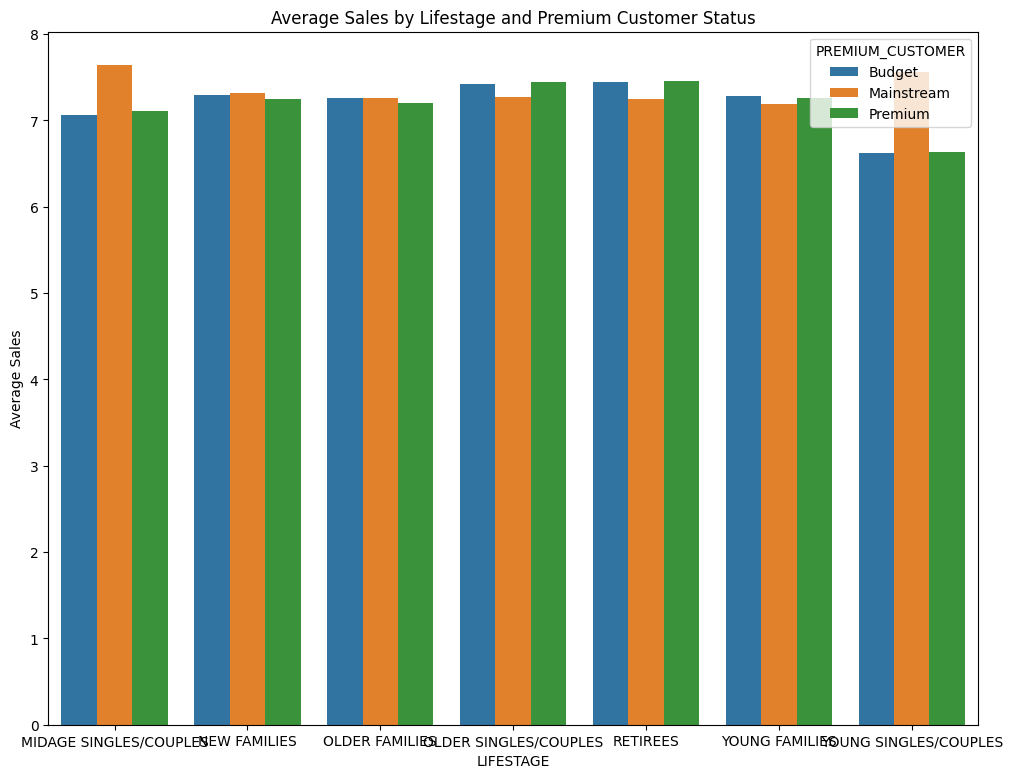

In [10]:
plt.figure(figsize=(12,9))
sns.barplot(data=Average_Control_Group,x='LIFESTAGE',y='Average Sales',hue='PREMIUM_CUSTOMER')
plt.title('Average Sales by Lifestage and Premium Customer Status')

plt.show()

In [11]:
Average_Trial_Group=Trial_Group.groupby(['LIFESTAGE','PREMIUM_CUSTOMER'])['TOT_SALES'].mean().reset_index(name='Average Sales')

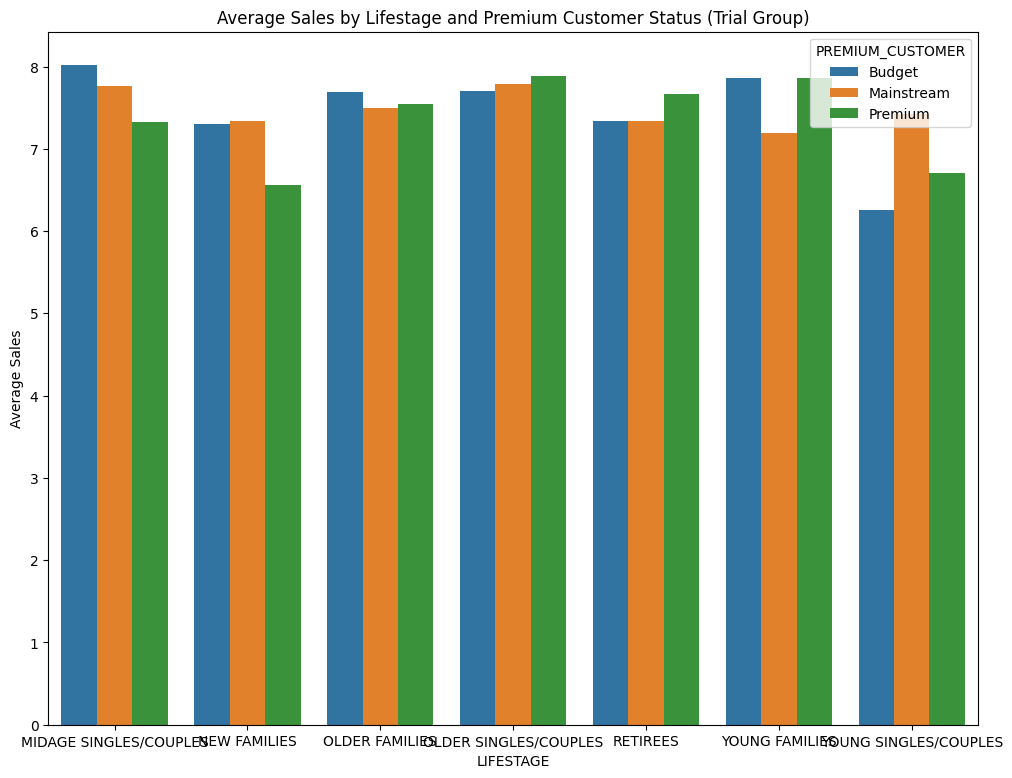

In [12]:
plt.figure(figsize=(12,9))
sns.barplot(data=Average_Trial_Group,x='LIFESTAGE',y='Average Sales',hue='PREMIUM_CUSTOMER')
plt.title('Average Sales by Lifestage and Premium Customer Status (Trial Group)')   
plt.show()

In [13]:
Average1_Cotrol_Group=Control_Group.groupby(['LIFESTAGE','PREMIUM_CUSTOMER'])['PROD_QTY'].mean().reset_index(name='Average Product Quantity')

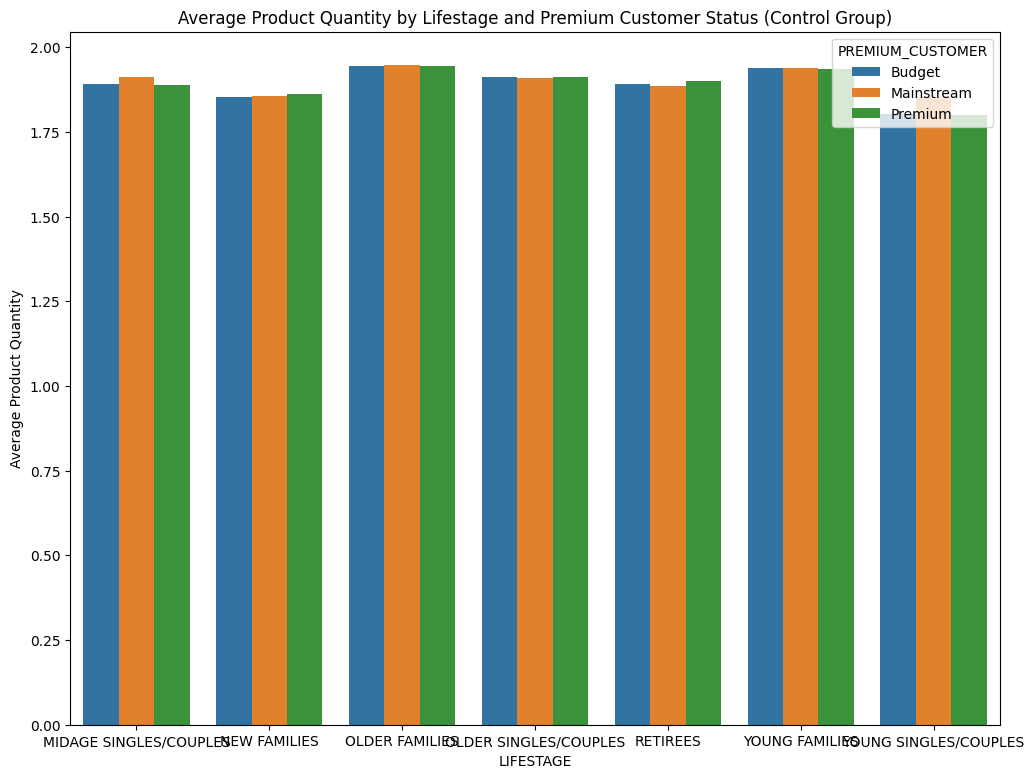

In [14]:
plt.figure(figsize=(12,9))
sns.barplot(data=Average1_Cotrol_Group, x='LIFESTAGE', y='Average Product Quantity', hue='PREMIUM_CUSTOMER')
plt.title('Average Product Quantity by Lifestage and Premium Customer Status (Control Group)')
plt.show()

In [15]:
Average1_Trial_Group=Trial_Group.groupby(['LIFESTAGE','PREMIUM_CUSTOMER'])['PROD_QTY'].mean().reset_index(name='Average Product Quantity')

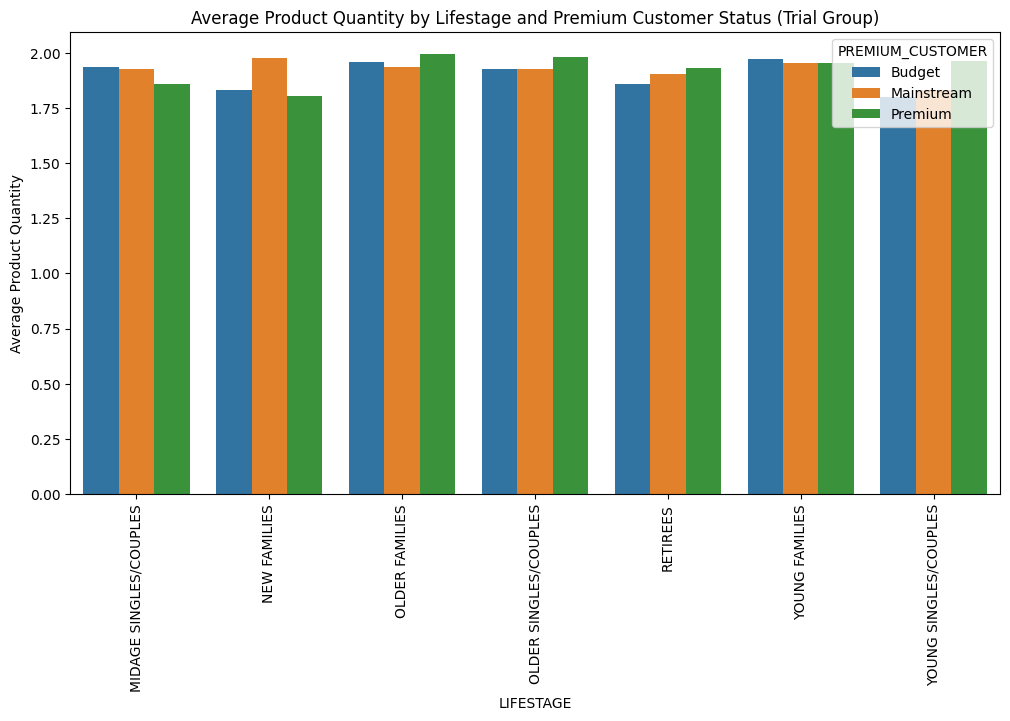

In [16]:
plt.figure(figsize=(12,6))
sns.barplot(data=Average1_Trial_Group, x='LIFESTAGE', y='Average Product Quantity', hue='PREMIUM_CUSTOMER')
plt.title('Average Product Quantity by Lifestage and Premium Customer Status (Trial Group)')
plt.xticks(rotation=90)
plt.show()

In [17]:
Average_Trial_Group=Trial_Group.groupby(['STORE_NBR','LIFESTAGE'])['TOT_SALES'].mean().reset_index(name='Average Sales')
Average_Trial_Group

,STORE_NBR,LIFESTAGE,Average Sales
0,77,MIDAGE SINGLES/COUPLES,5.125000
1,77,NEW FAMILIES,5.407407
2,77,OLDER FAMILIES,5.440625
3,77,OLDER SINGLES/COUPLES,5.667677
4,77,RETIREES,5.255882
5,77,YOUNG FAMILIES,5.769565
6,77,YOUNG SINGLES/COUPLES,5.294702
7,86,MIDAGE SINGLES/COUPLES,6.859055
8,86,NEW FAMILIES,7.086000
9,86,OLDER FAMILIES,6.832615


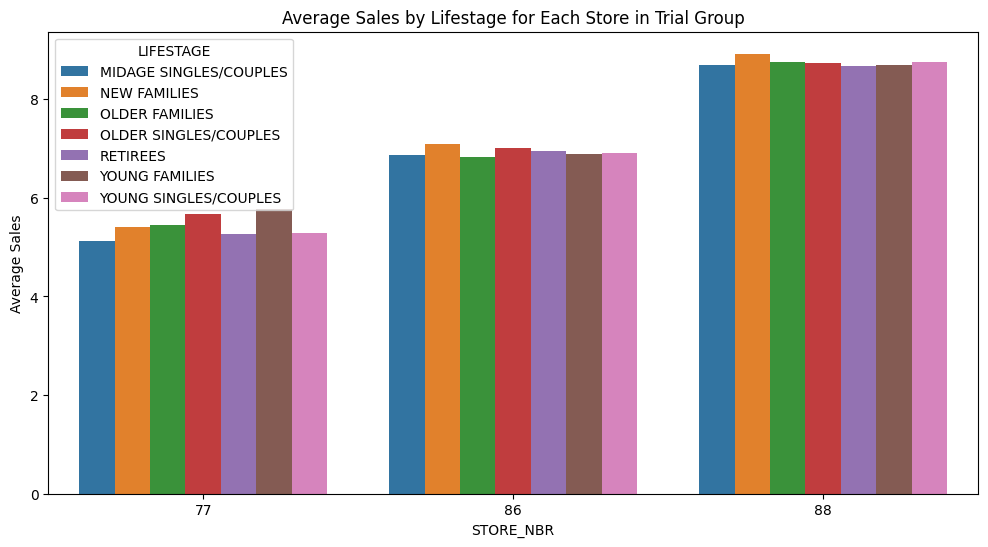

In [18]:
plt.figure(figsize=(12,6))
sns.barplot(data=Average_Trial_Group, x='STORE_NBR', y='Average Sales', hue='LIFESTAGE')
plt.title('Average Sales by Lifestage for Each Store in Trial Group')
plt.show()

In [19]:
Average_Trial_Group2=Trial_Group.groupby(['STORE_NBR','PREMIUM_CUSTOMER'])['TOT_SALES'].mean().reset_index(name='Average Sales')
Average_Trial_Group2

,STORE_NBR,PREMIUM_CUSTOMER,Average Sales
0,77,Budget,5.469543
1,77,Mainstream,5.453425
2,77,Premium,5.225850
3,86,Budget,6.939940
4,86,Mainstream,6.962440
5,86,Premium,6.814833
6,88,Budget,8.654381
7,88,Mainstream,8.687166
8,88,Premium,8.843389


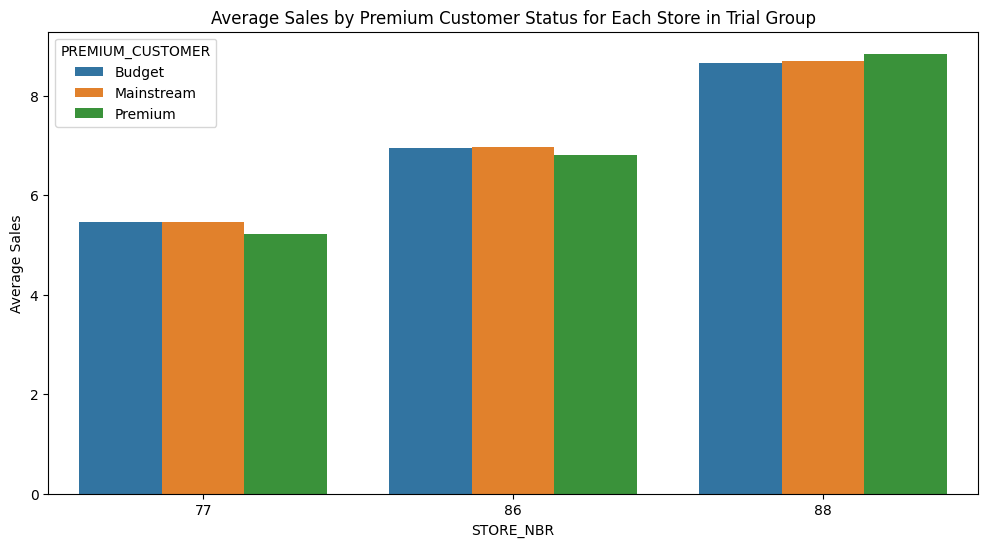

In [20]:
plt.figure(figsize=(12,6))
sns.barplot(data=Average_Trial_Group2, x='STORE_NBR', y='Average Sales', hue='PREMIUM_CUSTOMER')
plt.title('Average Sales by Premium Customer Status for Each Store in Trial Group')
plt.show()

In [21]:
Daily_Avg=df.groupby(['DATE'])['TOT_SALES'].mean()
Daily_Avg

DATE
2018-07-01    7.420166
2018-07-02    7.475949
2018-07-03    7.370914
2018-07-04    7.436835
2018-07-05    7.136096
                ...   
2019-06-26    7.337483
2019-06-27    7.338223
2019-06-28    7.259726
2019-06-29    7.379329
2019-06-30    7.289516
Name: TOT_SALES, Length: 364, dtype: float64

In [22]:
Trial_Date=Trial_Group['DATE'].unique()

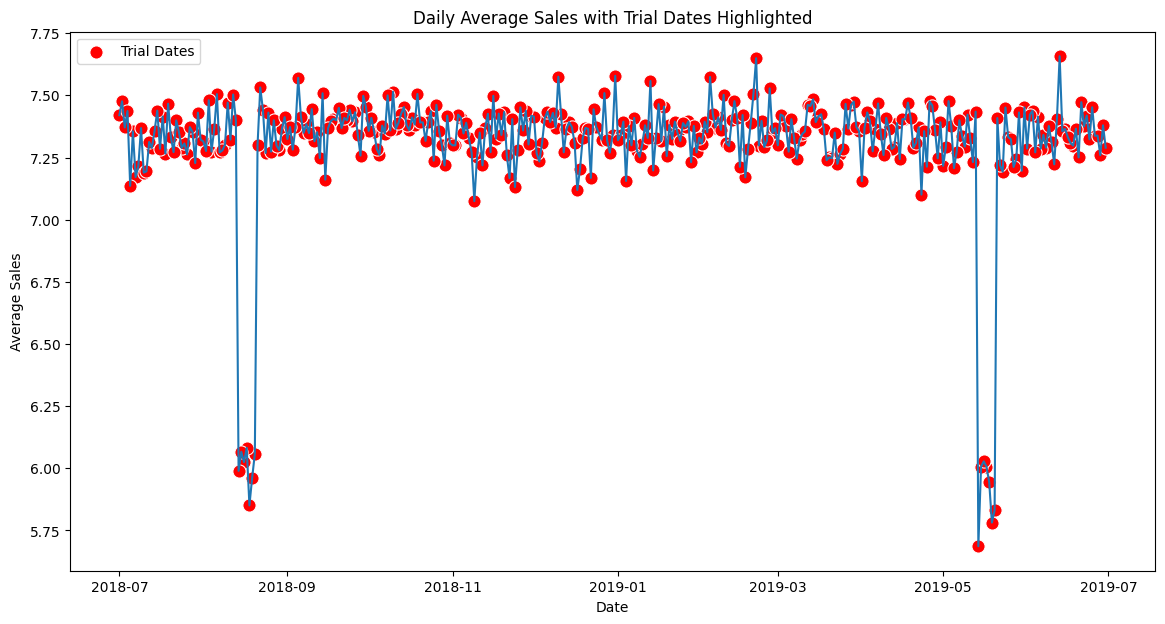

In [23]:
plt.figure(figsize=(14,7))
sns.lineplot(x=Daily_Avg.index, y=Daily_Avg.values)
sns.scatterplot(x=Trial_Date, y=Daily_Avg[Trial_Date], color='red', s=90, label='Trial Dates')
plt.title('Daily Average Sales with Trial Dates Highlighted')
plt.xlabel('Date')
plt.ylabel('Average Sales')
plt.legend()
plt.show()

In [24]:
Trial_Group

,LYLTY_CARD_NBR,DATE,STORE_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND,LIFESTAGE,PREMIUM_CUSTOMER
73365,77000,2019-03-28,77,74911,18,Cheetos Chs & Bacon Balls 190g,1,3.3,190,CHEETOS,MIDAGE SINGLES/COUPLES,Budget
73366,77000,2019-04-13,77,74912,69,Smiths Chip Thinly S/Cream&Onion 175g,1,3.0,175,SMITHS,MIDAGE SINGLES/COUPLES,Budget
73367,77000,2018-09-26,77,74910,36,Kettle Chilli 175g,2,10.8,175,KETTLE,MIDAGE SINGLES/COUPLES,Budget
73368,77001,2019-02-27,77,74913,7,Smiths Crinkle Original 330g,2,11.4,330,SMITHS,YOUNG FAMILIES,Mainstream
73369,77001,2019-01-21,77,74914,9,Kettle Tortilla ChpsBtroot&Ricotta 150g,2,9.2,150,KETTLE,YOUNG FAMILIES,Mainstream
...,...,...,...,...,...,...,...,...,...,...,...,...
264829,2370701,2018-12-08,88,240378,24,Grain Waves Sweet Chilli 210g,2,7.2,210,GRNWVES,YOUNG FAMILIES,Mainstream
264830,2370751,2018-10-01,88,240394,60,Kettle Tortilla ChpsFeta&Garlic 150g,2,9.2,150,KETTLE,YOUNG FAMILIES,Premium
264831,2370961,2018-10-24,88,240480,70,Tyrrells Crisps Lightly Salted 165g,2,8.4,165,TYRRELLS,OLDER FAMILIES,Budget
264832,2370961,2018-10-27,88,240481,65,Old El Paso Salsa Dip Chnky Tom Ht300g,2,10.2,300,OLD,OLDER FAMILIES,Budget


In [26]:
Trial_Group['TOT_SALES'].mean()-Control_Group['TOT_SALES'].mean()

np.float64(0.25572431260912776)

In [27]:
from scipy.stats import ttest_ind

In [30]:
t_stats, p = ttest_ind(Trial_Group['TOT_SALES'], Control_Group['TOT_SALES'], equal_var=False)
t_stats, p/2

(np.float64(6.557127925073612), np.float64(3.0830800260485484e-11))